In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("penguins_size.csv")

df["body_condition_index"] = df["body_mass_g"] / (df["flipper_length_mm"] ** 2)

numeric_cols = df.select_dtypes("number").columns

def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

for col in numeric_cols:
    for sp, group in df.groupby("species"):
        outliers_idx = find_outliers_iqr(group[col]).index
        df = df.drop(outliers_idx)

df = df.dropna(subset=["sex"])
df = df[df["sex"] != "."]

df = df.reset_index(drop=True)

In [2]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Классы умеренно несбалансированы

# kNN и дерево решений

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = df[numeric_cols]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

# Сравнение результатов

## Метрики оценки качества классификации

**Accuracy** -- доля правильно классифицированных объектов от общего числа объектов в тестовой выборке. 

**Precision (точность)** -- доля объектов, действительно принадлежащих классу, среди всех объектов, отнесённых моделью к этому классу. Отражает, насколько модель избегает ложных срабатываний.

**Recall (полнота)** -- доля объектов класса, которые модель правильно нашла, среди всех объектов, реально принадлежащих этому классу. Отражает, насколько модель не пропускает представителей класса.

**F-measure (F1-score)** -- гармоническое среднее Precision и Recall. Объединяет обе метрики в одно значение и особенно полезен, когда важен баланс между ними, а не только одна из сторон.

**ROC-кривая** -- график зависимости доли истинноположительных срабатываний (TPR) от доли ложноположительных срабатываний (FPR) при варьировании порога классификации. Показывает способность модели разделять классы по предсказанным вероятностям, а не только по итоговому решению.

**AUC (площадь под ROC-кривой)** -- числовая мера качества классификатора, принимающая значения от 0 до 1. Значение, близкое к 1, означает высокую способность модели разделять классы; значение 0.5 соответствует случайному угадыванию.

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import pandas as pd


results = pd.DataFrame({
    "Model": ["kNN", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, knn_pred), accuracy_score(y_test, tree_pred)],
    "Precision": [
        precision_score(y_test, knn_pred, average="macro"),
        precision_score(y_test, tree_pred, average="macro")
    ],
    "Recall": [
        recall_score(y_test, knn_pred, average="macro"),
        recall_score(y_test, tree_pred, average="macro")
    ],
    "F-measure": [
        f1_score(y_test, knn_pred, average="macro"),
        f1_score(y_test, tree_pred, average="macro")
    ]
})

results

,Model,Accuracy,Precision,Recall,F-measure
0,kNN,0.969231,0.978495,0.948718,0.961111
1,Decision Tree,0.969231,0.978495,0.948718,0.961111


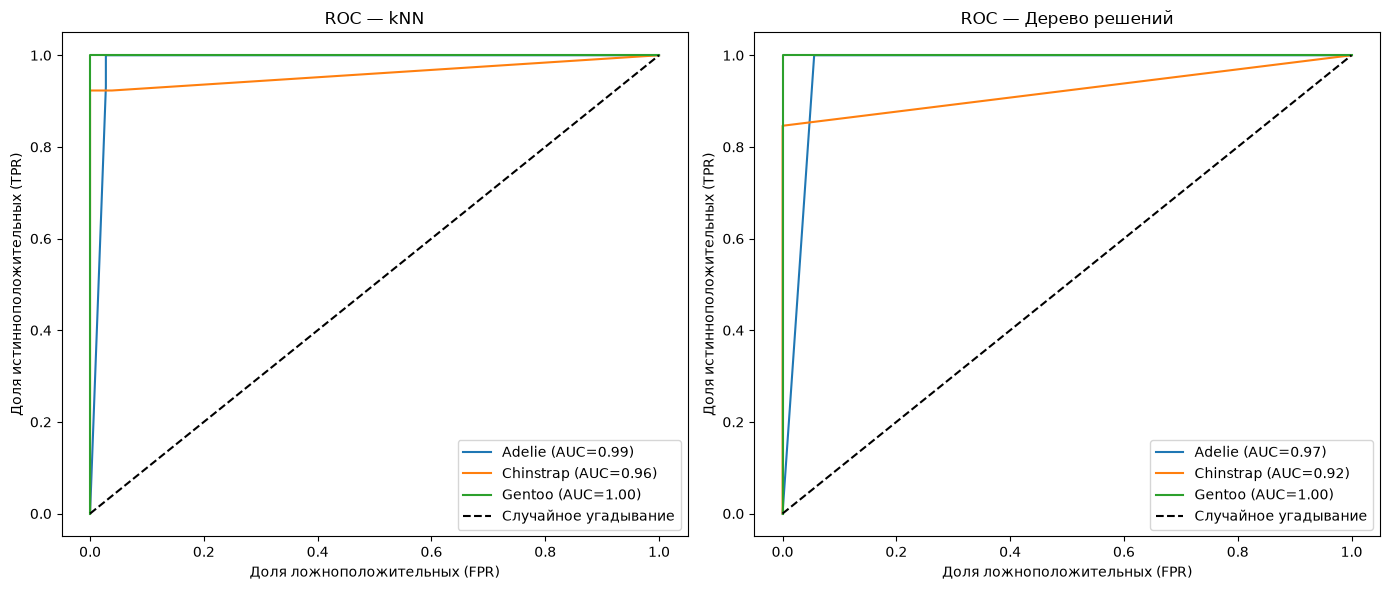

In [ ]:
classes = df["species"].unique()
y_test_bin = label_binarize(y_test, classes=classes)

knn_proba = knn.predict_proba(X_test_scaled)
tree_proba = tree.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], knn_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], knn_proba[:, i])
    axes[0].plot(fpr, tpr, label=f"{cls} (AUC={auc:.2f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Случайное угадывание")
axes[0].set_xlabel("Доля ложноположительных (FPR)")
axes[0].set_ylabel("Доля истинноположительных (TPR)")
axes[0].set_title("ROC -- kNN")
axes[0].legend()

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], tree_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], tree_proba[:, i])
    axes[1].plot(fpr, tpr, label=f"{cls} (AUC={auc:.2f})")

axes[1].plot([0, 1], [0, 1], "k--", label="Случайное угадывание")
axes[1].set_xlabel("Доля ложноположительных (FPR)")
axes[1].set_ylabel("Доля истинноположительных (TPR)")
axes[1].set_title("ROC -- Дерево решений")
axes[1].legend()

plt.tight_layout()
plt.show()

## Сравнение результатов классификации

**Accuracy, Precision, Recall, F-measure.** Обе модели показали одинаковый результат. Оба алгоритма справляются с ней практически одинаково хорошо.

**ROC-кривые.** Для всех трёх видов на обеих моделях кривые проходят близко к левому верхнему углу -- значения AUC от 0.92 до 1.00. Это означает, что модели почти безошибочно разделяют классы по предсказанным вероятностям.

Gentoo классифицируется идеально в обеих моделях (AUC = 1.00) -- этот вид визуально сильнее всего отделён от остальных по признакам (что подтверждалось ранее на диаграммах рассеивания с culmen_depth_mm).

Chinstrap -- самый слабый результат из трёх видов в обеих моделях (AUC 0.96 у kNN, 0.92 у дерева решений). Chinstrap -- самый малочисленный класс в датасете.


Оба алгоритма показывают высокое качество классификации на данном датасете.